In [12]:
import kagglehub
import pandas as pd
import os

# 1. Descargar el dataset
path = kagglehub.dataset_download("blastchar/telco-customer-churn")

# 2. Localizar el archivo CSV
csv_file = [f for f in os.listdir(path) if f.endswith('.csv')][0]
full_path = os.path.join(path, csv_file)

# 3. Leer con Pandas
df = pd.read_csv(full_path)

print("🚀 ¡Éxito total! Datos cargados.")
print(f"Registros: {df.shape[0]}")
df.head()

🚀 ¡Éxito total! Datos cargados.
Registros: 7043


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [13]:
# 1. Ver información general de las columnas
print(df.info())

# 2. Limpieza de TotalCharges: Convertir a número (los errores se vuelven NaN)
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

# 3. Eliminar filas con valores nulos (normalmente son solo 11)
df.dropna(inplace=True)

print(f"\n✅ Datos limpios. Filas restantes: {len(df)}")

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

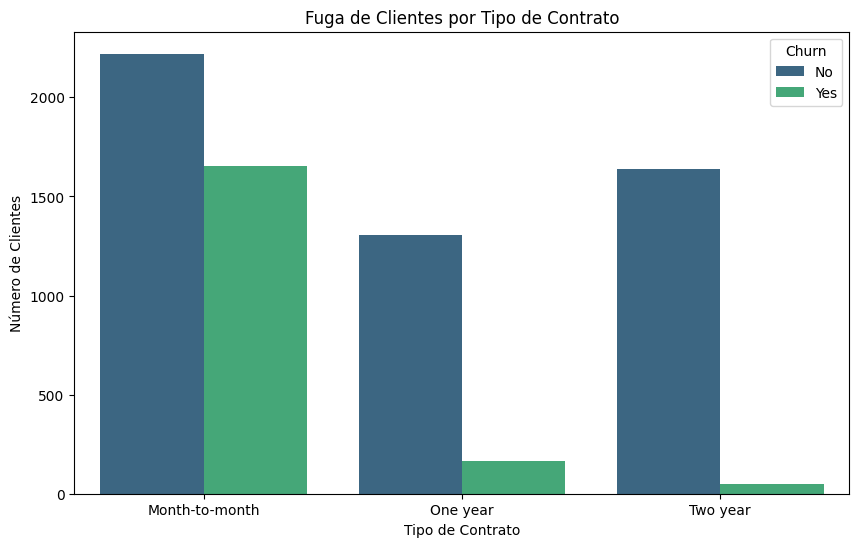

Porcentaje de fuga total:
Churn
No     73.421502
Yes    26.578498
Name: proportion, dtype: float64


In [14]:
#Convertir a número (los errores se vuelven NaN)
df['TotalCharges']= pd.to_numeric(df['TotalCharges'], errors='coerce')

#Eliminacion filas nulas
df.dropna(subset=['TotalCharges'], inplace=True)

#Analisis visual porque se van los clientes ?

import seaborn as sns
import matplotlib.pyplot   as plt

plt.figure(figsize=(10,6))
#Relacion entre el tipo de contrato y la fuga
sns.countplot(data=df, x='Contract', hue='Churn', palette='viridis')
plt.title('Fuga de Clientes por Tipo de Contrato')
plt.xlabel('Tipo de Contrato')
plt.ylabel('Número de Clientes')
plt.show()

# 3. Ver el porcentaje real de fuga
print("Porcentaje de fuga total:")
print(df['Churn'].value_counts(normalize=True) * 100)

In [15]:
# Convertimos la variable objetivo 'Churn' a numérica para la correlación
df_numeric = df.copy()
df_numeric['Churn'] = df_numeric['Churn'].map({'Yes': 1, 'No': 0})

# Seleccionamos solo las columnas numéricas para el mapa de calor
# (Antigüedad, Cargos Mensuales, Cargos Totales y nuestro nuevo Churn numérico)
corr_matrix = df_numeric[['tenure', 'MonthlyCharges', 'TotalCharges', 'Churn']].corr()

print("Matriz de correlación calculada correctamente.")

Matriz de correlación calculada correctamente.


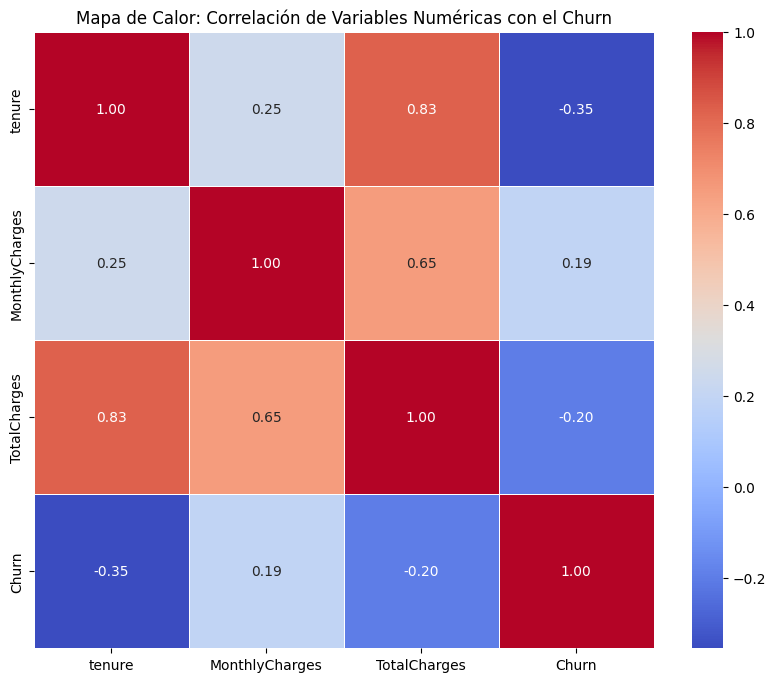

In [16]:
#Crear el mapa de calor
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Mapa de Calor: Correlación de Variables Numéricas con el Churn')
plt.show()

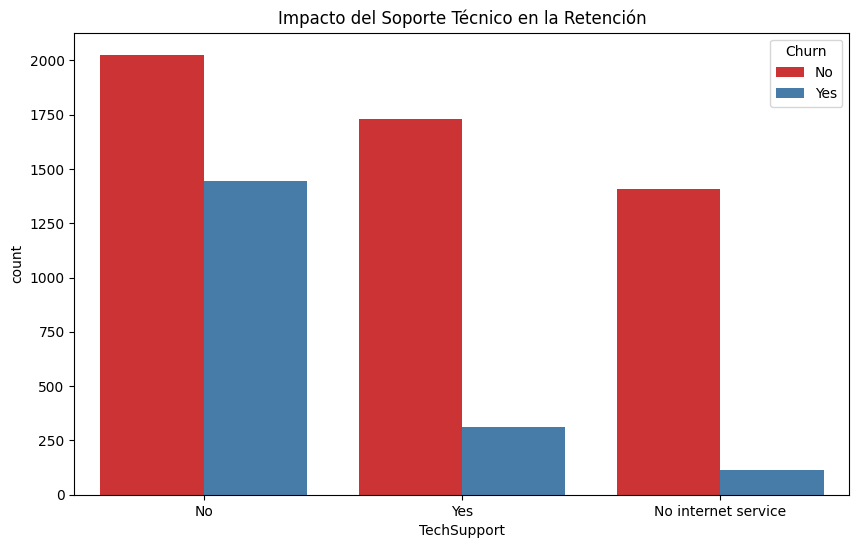

In [17]:
#Tener soporte tecnico ayuda o no
plt.figure(figsize=(10, 6))
sns.countplot(data=df, x='TechSupport', hue='Churn', palette='Set1')
plt.title('Impacto del Soporte Técnico en la Retención')
plt.show()

--------------------------------------------------
📝 RESUMEN EJECUTIVO PARA EL PORTAFOLIO
--------------------------------------------------
📊 Tasa General de Fuga: 26.58%
🚩 Alerta Roja: Los clientes con contrato 'Mes a Mes' se fugan un 42.71%.
🛠️ Oportunidad: Los clientes sin Soporte Técnico tienen una fuga del 41.65%.
--------------------------------------------------


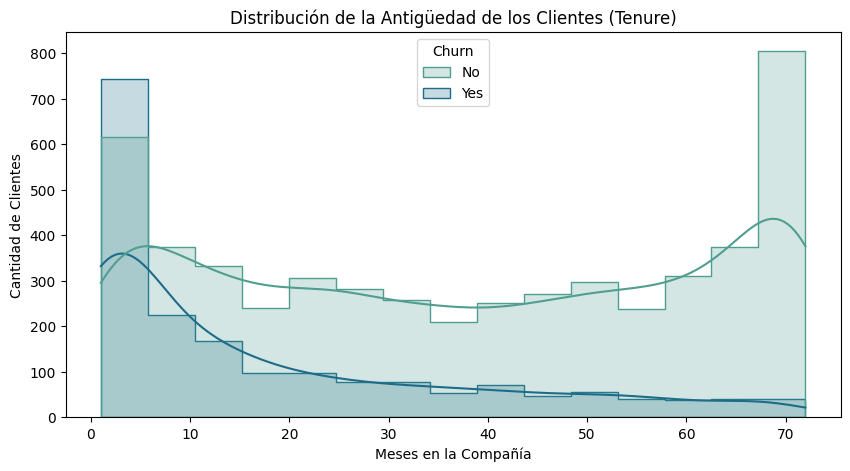

In [ ]:
# 1. Calculamos los hallazgos clave
fuga_total = df['Churn'].value_counts(normalize=True)['Yes'] * 100
fuga_mes_a_mes = df[df['Contract'] == 'Month-to-month']['Churn'].value_counts(normalize=True)['Yes'] * 100
fuga_sin_soporte = df[df['TechSupport'] == 'No']['Churn'].value_counts(normalize=True)['Yes'] * 100

# 2. Imprimimos el Resumen Ejecutivo
print("-" * 50)
print("📝 RESUMEN EJECUTIVO P")
print("-" * 50)
print(f"📊 Tasa General de Fuga: {fuga_total:.2f}%")
print(f"🚩 Alerta Roja: Los clientes con contrato 'Mes a Mes' se fugan un {fuga_mes_a_mes:.2f}%.")
print(f"🛠️ Oportunidad: Los clientes sin Soporte Técnico tienen una fuga del {fuga_sin_soporte:.2f}%.")
print("-" * 50)

# 3. Una última visualización de impacto: Distribución de antigüedad
plt.figure(figsize=(10, 5))
sns.histplot(data=df, x='tenure', hue='Churn', kde=True, element="step", palette='crest')
plt.title('Distribución de la Antigüedad de los Clientes (Tenure)')
plt.xlabel('Meses en la Compañía')
plt.ylabel('Cantidad de Clientes')
plt.show()